# Quantum-Inspired Acromyrmex Evolutionary Algorithm (QIAEA) in Graph Clustering

The notebook contains first experimental algorithm implementation for graph clustering problem via QIAEA.

The graph for algorithm is built on the dataset "Relato Business Graph Database", that can be downloaded by <a href="https://www.kaggle.com/datasets/thedevastator/relato-business-network-graph-373663-domain-conn">link</a>.

Structure of the notebook is the following:

1. Data Preprocessing;

2. Models Declaration;

3. QIAEA Implementation;

4. Algorithms evaluation:
   
   1. QIAEA evaluation;
   
   2. Greedy Modularity Communities algorithm evaluation;
   
   3. Leiden algorithm evaluation;
   
   4. Newman-Girvan algorithm evaluation;

5. Algorithms Comparison.

**Library import**

In [1]:
!pip install igraph
!pip install numpy
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.8 MB/s eta 0:00:00


In [2]:
from igraph import Graph, VertexClustering
import matplotlib.pyplot as plt
from collections import Counter
from igraph import plot
import pandas as pd
import numpy as np
import json

## Data Preprocessing

---
**Data Download & Cleaning**

In [3]:
links = pd.read_csv("links.csv")
links = links.drop(['index', '_id', 'update_time', 'home_domain', 'link_domain', 'username', 'name'], axis=1)
links = links.dropna()
links = links[links['type'] == 'partnership'].drop(['type'], axis=1)
links = links.drop_duplicates()

links.head()

<ipython-input-3-550a0506daea>:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  links = pd.read_csv("links.csv")


,home_name,link_name
0,F5 Networks,Dell
1,F5 Networks,AT&T
2,F5 Networks,Verizon
3,F5 Networks,Hewlett Packard
4,F5 Networks,IBM


---
**Companies extraction and reduction**

In [4]:
VERTICES_NUMBER = 1000

# get number of relationship for each company
def get_company_degrees(companies: list) -> list:
    return sorted(list(Counter(companies).items()), key=lambda x: -x[1])

# extract companies from the pandas table
# number of occurrencies of each company in the array equal to the degreeof the company
companies = np.concatenate(
        (links['home_name'], links['link_name'])
        ).astype('str')
# get sorted by degree list of the companies in decreasing order
sorted_companies = np.array([elem[0] for elem in get_company_degrees(companies)])
# reduce the number of companies
companies = sorted_companies[370:370+VERTICES_NUMBER]

# create dict that maps company name by index in companies list
map_companies = dict()
for idx, company in enumerate(companies):
    map_companies[company] = idx

print(f"Sample company: {companies[0]}")

Sample company: Itron


---
**Relationship extraction for given list of companies**

In [5]:
edges = set()
for link in links.values:
    if (map_companies.get(link[0], '') != '') and (map_companies.get(link[1], '') != ''):
        company1 = min(map_companies[link[0]], map_companies[link[1]])
        company2 = max(map_companies[link[0]], map_companies[link[1]])
        edges.add((company1, company2))

edges = np.array(list(edges))
print(f"Number of edges: {len(edges)}")

Number of edges: 4632


## Models Declaration

In [6]:
# Network is a graph that contains the companies as vertices and relationship as edges.
# The class provides method for fast calculating of modularity score of partition.
class Network:
    def __init__(self, vertices: np.ndarray, edges: np.ndarray):
        self.number_of_vertices = len(vertices)
        self.number_of_edges = len(edges)
        self.vertices = vertices
        self.edges = edges
        assert edges.shape[1] == 2

        self.degrees = np.zeros((self.number_of_vertices,))
        for edge in edges:
            self.degrees[edge[0]] += 1
            self.degrees[edge[1]] += 1

        self.adjacency_list = [[] for _ in range(self.number_of_vertices)]
        for edge in edges:
            self.adjacency_list[edge[0]].append(edge[1])
            self.adjacency_list[edge[1]].append(edge[0])
        self.adjacency_list = [np.array(elem) for elem in self.adjacency_list]

    def modularity(self, labels: np.ndarray, k_max: int):
        degree_per_cluster = np.bincount(labels, self.degrees, minlength=k_max)

        from_clusters = labels[self.edges[:, 0]]
        to_clusters = labels[self.edges[:, 1]]

        mask = (from_clusters == to_clusters)

        edges_per_cluster = np.bincount(from_clusters[mask], minlength=k_max).astype('int32')

        modularity = np.sum(edges_per_cluster / self.number_of_edges) - np.sum((degree_per_cluster / (2 * self.number_of_edges)) ** 2)

        return modularity


# The class represents a clustering of graph. The class is implemented with qubits and
# is adapted for evolutionary operations.
class Partition:
    def __init__(self, number_of_vertices: np.ndarray, k_max: int, chromosome_values: np.ndarray = None):
        assert k_max < 256
        self.number_of_vertices = number_of_vertices
        self.k_max = k_max
        self.fitness = 0
        self.gene_len = 1

        while 2**(self.gene_len) < k_max:
            self.gene_len += 1

        self.chromosome = np.random.randint(2, size=(number_of_vertices, self.gene_len, 2)).astype('float64')
        random_values = np.random.uniform(low=0, high=0.0001, size=(number_of_vertices, self.gene_len, 2))
        self.chromosome = np.where(self.chromosome == 1, self.chromosome - random_values, self.chromosome + random_values)
        if chromosome_values:
            self.chromosome = chromosome_values.astype('float64')
        self.chromosome[:, :, 1] = np.sqrt(1 - self.chromosome[:, :, 0]**2)
        self.collapsed_chromosome = None

    def __copy__(self):
        obj = Partition(self.number_of_vertices, self.k_max)
        obj.fitness = self.fitness
        obj.gene_len = self.gene_len
        obj.chromosome = np.copy(self.chromosome)
        obj.collapsed_chromosome = np.copy(self.collapsed_chromosome)
        return obj

    def collapse(self):
        labels = np.zeros((self.number_of_vertices,), dtype='int32')
        measure = np.random.uniform(size=(self.chromosome.shape[0], self.chromosome.shape[1]))
        measured_chromosome = (self.chromosome[:, :, 0]**2) >= (measure**2)
        labels = np.packbits(measured_chromosome, axis=1, bitorder='little').flatten()
        labels = labels % self.k_max
        self.collapsed_chromosome = labels

    def calculate_fitness(self, graph: Network):
        self.fitness = graph.modularity(self.collapsed_chromosome, self.k_max)

    def mutation(self, graph: Network, number_of_mutations: int = 1):
        assert number_of_mutations >= 1

        new_partition = Partition(self.number_of_vertices, self.k_max)
        new_partition.chromosome = np.copy(self.chromosome)

        while True:
            center_vertex = np.random.randint(0, self.number_of_vertices)
            if len(graph.adjacency_list[center_vertex]) > 0:
                break

        candidate_vertices = np.random.choice(graph.adjacency_list[center_vertex], number_of_mutations)

        for vertex in candidate_vertices:
            new_partition.chromosome[vertex] = new_partition.chromosome[center_vertex]

        return new_partition

    def to_dict(self):
        return {
            "number_of_vertices": self.number_of_vertices,
            "k_max": self.k_max,
            "chromosome_values": self.chromosome.tolist()
        }


def crossover(partition1: Partition, partition2: Partition) -> Partition:
    child = Partition(partition1.number_of_vertices, partition1.k_max)

    adamart_operator = np.array([
        [1, 1],
        [1, -1]
    ]) / np.sqrt(2)

    xgate_operator = np.array([
        [0, 1],
        [1, 0]
    ])

    mask_adamart = (partition1.collapsed_chromosome == partition2.collapsed_chromosome)
    mask_xgate = (partition1.collapsed_chromosome != partition2.collapsed_chromosome)
    child.chromosome[mask_adamart] = child.chromosome[mask_adamart] @ adamart_operator.T
    child.chromosome[mask_xgate] = child.chromosome[mask_xgate] @ xgate_operator.T
    return child

## QIAEA Implementation

---
**Main function for execution QIAEA algorithm**

In [7]:
def run_qiaea(population_size: int, number_of_vertices: int, number_of_males: int, max_number_of_clusters: int,
              number_of_epochs: int, graph: Network, queen_lifetime_epochs: int = 20):

    # history of fitnesses changes over evolutions
    training_history = []

    # number of males in population must be less than population size
    assert number_of_males < population_size

    # initiate population with random solutions
    population = [Partition(number_of_vertices, max_number_of_clusters) for _ in range(population_size)]

    # calculate fitness and measure of initial population
    for partition in population:
        partition.collapse()
        partition.calculate_fitness(graph)
    population.sort(key=lambda x: -x.fitness)

    # the best solution has the best fitness
    best_solution = population[0].__copy__()

    # main training loop
    for epoch in range(0, number_of_epochs):
        # Crossover operations
        for i in range(1, number_of_males+1):
            population.append(crossover(population[0], population[i]))

        # Mutation operations
        for i in range(1, population_size+1):
            population.append(population[i].mutation(graph, 20))

        # Measure operations
        for i in range(population_size, len(population)):
            population[i].collapse()

        # Fitness calculation
        for i in range(population_size, len(population)):
            population[i].calculate_fitness(graph)
        population.sort(key=lambda x: -x.fitness)

        # Queen and unadapted members elimination operation
        if epoch % queen_lifetime_epochs == 0:
            population = population[1:population_size+1]
        else:
            population = population[:population_size]

        # update the best solution
        if population[0].fitness > best_solution.fitness:
            best_solution = population[0].__copy__()

        # add current queen's fitness to training history
        training_history.append(population[0].fitness)

        # the training log is output every 50 epochs
        if epoch % 50 == 0:
            print(f"Epoch {epoch+1}, queen fitness: {population[0].fitness:.6f}, best fitness: {best_solution.fitness:.6f}")

    return (best_solution, population, training_history)

## Algorithms evaluation

---
**QIAEA evaluation**

The QIAEA has the following hyperparameters:

  1) Population size. We set population size to be equal 200 based on empirical calculations. The more size of the population, the slower the fitness of queen will converge. The less size of the population, the more probability that the solutions will be stuck in local optimum;
    
  2) Number of epochs. Actually, our algorithm is not bounded by single execution. The population that was evolved can be stored, and executed in subsequent executions. We set the number of epochs to be equal 8000, as soon as the next generations have very small amount of changes in fitness function.
    
  3) Maximum number of clusters. The general advice is to set maximum number of cluster to be less than sqrt(n), where n - number of vertices. This advice is general and should be adjusted according to the certain graph structure. We set the maximum number of clusters to be 32.

  4) Queen lifetime in epochs. As soon as, our algorithm uses queen elimination operation, the queen lifetime in epochs must be set. The hyperparameter can help to avoid getting stuck in local optimum. Too low value of hyperparameter can impede search for optimum, while too high value can lead to convergence to local opimum. Based on empirical observations, we set the queen lifetime epochs to be equal 200.

The current overall QIAEA implementation explanations can be read in report.pdf in github [repository](https://github.com/Nature-Inspired-Computing-Team/NIC-Project).

In [8]:
# This code utilize the Graph class from igraph library and populates it with current vertices and edges
# The graph will be used later in calculation modularity and plotting figures.
graph = Graph(directed=False)
graph.add_vertices(VERTICES_NUMBER)
graph.add_edges(edges)
graph.vs['name'] = companies

In [9]:
# Execution of QIAEA algorithm
network = Network(companies, edges)
population_size = 200
epochs = 8001
max_number_of_clusters = 32
best_solution, population, training_history = run_qiaea(population_size, VERTICES_NUMBER, population_size//2,
                                                        max_number_of_clusters, epochs, network, 200)

Epoch 1, queen fitness: 0.006651, best fitness: 0.006651
Epoch 51, queen fitness: 0.086615, best fitness: 0.086615
Epoch 101, queen fitness: 0.141064, best fitness: 0.141064
Epoch 151, queen fitness: 0.182943, best fitness: 0.182943
Epoch 201, queen fitness: 0.214252, best fitness: 0.214946
Epoch 251, queen fitness: 0.239903, best fitness: 0.239903
Epoch 301, queen fitness: 0.257566, best fitness: 0.257566
Epoch 351, queen fitness: 0.270772, best fitness: 0.270772
Epoch 401, queen fitness: 0.283290, best fitness: 0.283290
Epoch 451, queen fitness: 0.290115, best fitness: 0.290115
Epoch 501, queen fitness: 0.297466, best fitness: 0.297466
Epoch 551, queen fitness: 0.303139, best fitness: 0.303139
Epoch 601, queen fitness: 0.308119, best fitness: 0.308119
Epoch 651, queen fitness: 0.312679, best fitness: 0.312679
Epoch 701, queen fitness: 0.316314, best fitness: 0.316314
Epoch 751, queen fitness: 0.320024, best fitness: 0.320024
Epoch 801, queen fitness: 0.323125, best fitness: 0.323125


In [10]:
best_qiaea_clusters = VertexClustering(graph, best_solution.collapsed_chromosome)
best_qiaea_modularity = graph.modularity(best_qiaea_clusters.membership)
print(f"Modularity of QIAEA best solution: {best_qiaea_modularity}")

Modularity of QIAEA best solution: 0.3878868112790501


Let's illustrate the training progress

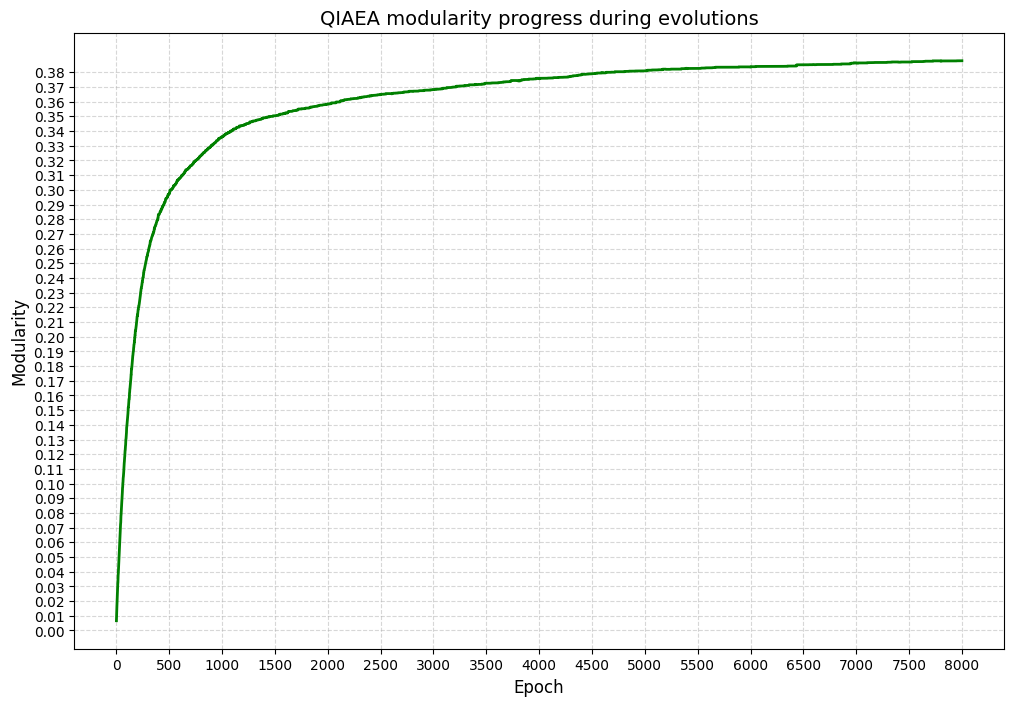

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))
plt.plot(training_history, color='green', linestyle='-', linewidth=2)

max_epoch = len(training_history)
xticks = np.arange(0, max_epoch, 500)
yticks = np.arange(0, 0.39, 0.01)
plt.xticks(xticks, labels=[f"{int(x)}" for x in xticks])
plt.yticks(yticks, labels=[f"{y:.2f}" for y in yticks])

# Оформление
plt.title("QIAEA modularity progress during evolutions", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Modularity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Also, let's store the training history to training_history.txt and population population.json files for further executions and analysis.

In [12]:
with open("training_history.txt", "w", encoding='utf-8') as file:
    for epoch_fitness in training_history:
        file.write(f"{epoch_fitness}\n")

with open("population_state.json", "w", encoding='utf-8') as file:
    population_dict = [solution.to_dict() for solution in population]
    json.dump(population_dict, file, indent=2)

---
**Greedy Modularity Communities algorithm evaluation**

The igraph implementation of the algorithm will be used. The main hyperparameter of the algorithm is the number of clusters. This code tries number of clusters from the low as possible to 256 to find the optimal solution.

In [18]:
best_greedy_modularity, best_greedy_clusters = 0, []
dendrogram = graph.community_fastgreedy()
for number_of_clusters in range(0, 256):
    try:
        greedy_clusters = dendrogram.as_clustering(number_of_clusters)
        greedy_modularity = graph.modularity(greedy_clusters.membership)
        if greedy_modularity > best_greedy_modularity:
            best_greedy_modularity = greedy_modularity
            best_greedy_clusters = greedy_clusters
    except Exception as error:
        pass

print(f"Modularity of Greedy algorithm best solution: {best_greedy_modularity}")

Modularity of Greedy algorithm best solution: 0.3771447490387512


---
**Leiden algorithm evaluation**

The igraph implementation of the algorithm will be used. The main hyperparameter of the algorithms is the resolution that is in the interval [0, 1]. The higher the resolution the more clusters will be created, the less the resolution the less clusters will be created. This code tries resolution from 0 to 1 with step 0.001 to find the optimal resolution.

In [19]:
best_leiden_modularity, best_leiden_clusters = 0, []
for resolution_int in range(0, 1000):
    resolution = resolution_int / 1000
    leiden_clusters = graph.community_leiden(resolution=resolution)
    leiden_modularity = graph.modularity(leiden_clusters.membership)
    if leiden_modularity > best_leiden_modularity:
        best_leiden_modularity = leiden_modularity
        best_leiden_clusters = leiden_clusters
print(f"Modularity of Leiden algorithm best solution: {best_leiden_modularity}")

Modularity of Leiden algorithm best solution: 0.3859754764109998


---
**Newman-Girvan algorithm evaluation**

The igraph implementation of the algorithm will be used. The main hyperparameter of the algorithm is the number of clusters. This code tries number of clusters from the low as possible to 256 to find the optimal solution.

In [20]:
best_ng_modularity, best_ng_clusters = 0, []
dendrogram = graph.community_edge_betweenness()
for number_of_clusters in range(0, 256):
    try:
        ng_clusters = dendrogram.as_clustering(number_of_clusters)
        ng_modularity = graph.modularity(ng_clusters.membership)
        if ng_modularity > best_ng_modularity:
            best_ng_modularity = ng_modularity
            best_ng_clusters = ng_clusters
    except Exception as error:
        pass

print(f"Modularity of Greedy algorithm best solution: {best_ng_modularity}")

Modularity of Greedy algorithm best solution: 0.26786795264451563


---
**Algorithms modularity comparison**

In [21]:
print(f"QIAEA modularity: {best_qiaea_modularity:.6f}")
print(f"Greedy algorithm modularity: {best_greedy_modularity:.6f}")
print(f"Leiden algorithm modularity: {best_leiden_modularity:.6f}")
print(f"Newman-Girvan algorithm modularity: {best_ng_modularity:.6f}")

QIAEA modularity: 0.387887
Greedy algorithm modularity: 0.377145
Leiden algorithm modularity: 0.385975
Newman-Girvan algorithm modularity: 0.267868


---
**Graph clustering visualization**

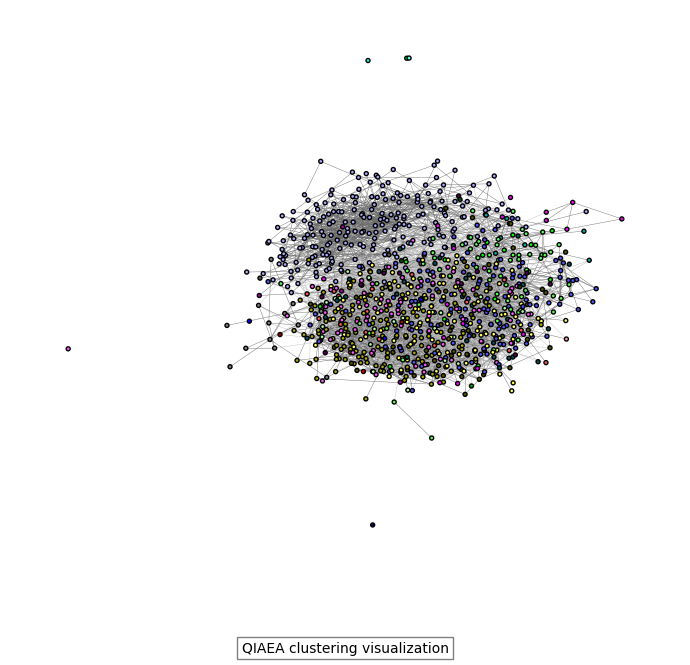

In [22]:
# Visualize QIAEA clustering
import matplotlib.pyplot as plt
from igraph import plot

fig, ax = plt.subplots(figsize=(7, 7))
layout = graph.layout("kk")
visual_style = {
    "vertex_color": [i for i in best_qiaea_clusters.membership],
    "vertex_size": 4,
    "edge_width": 0.3,
    "layout": layout,
    "target": ax,
    "bbox": (400, 400)
}

plot(best_qiaea_clusters, **visual_style)
caption = (
    f"QIAEA clustering visualization"
)
plt.figtext(
    0.5, 0.01,
    caption,
    ha="center",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.5, "pad": 3},
    wrap=True
)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

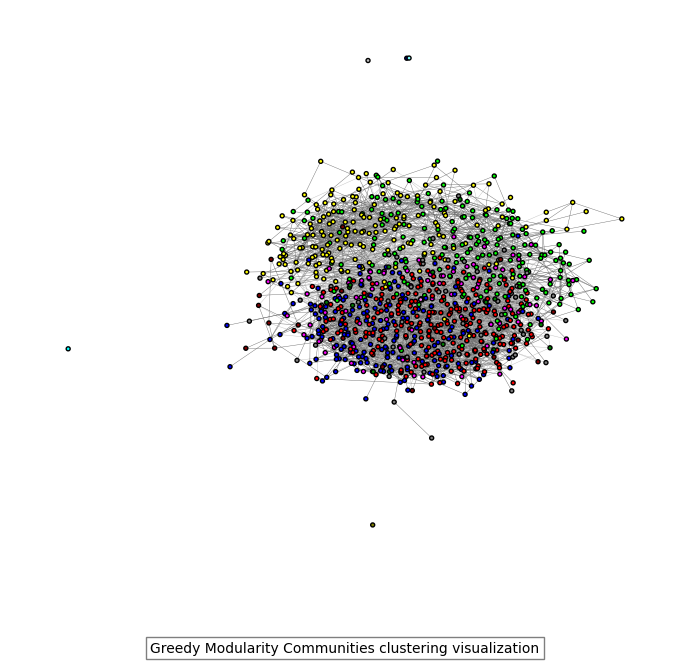

In [23]:
# Visualize Greedy Modularity Communities algorithm clustering
import matplotlib.pyplot as plt
from igraph import plot

fig, ax = plt.subplots(figsize=(7, 7))
layout = graph.layout("kk")
visual_style = {
    "vertex_color": [i for i in best_greedy_clusters.membership],
    "vertex_size": 4,
    "edge_width": 0.3,
    "layout": layout,
    "target": ax,
    "bbox": (400, 400)
}

plot(best_greedy_clusters, **visual_style)
caption = (
    f"Greedy Modularity Communities clustering visualization"
)
plt.figtext(
    0.5, 0.01,
    caption,
    ha="center",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.5, "pad": 3},
    wrap=True
)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

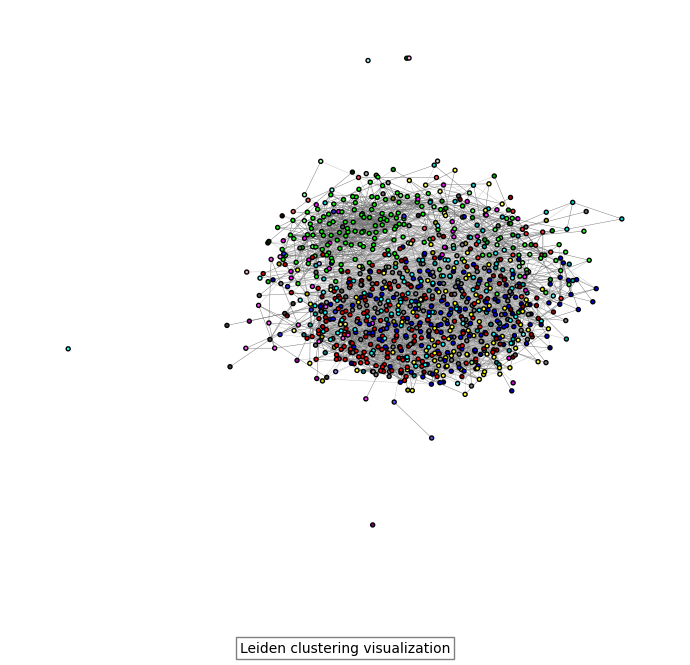

In [24]:
# Visualize Leiden algorithm clustering
import matplotlib.pyplot as plt
from igraph import plot

fig, ax = plt.subplots(figsize=(7, 7))
layout = graph.layout("kk")
visual_style = {
    "vertex_color": [i for i in best_leiden_clusters.membership],
    "vertex_size": 4,
    "edge_width": 0.3,
    "layout": layout,
    "target": ax,
    "bbox": (400, 400)
}

plot(best_leiden_clusters, **visual_style)
caption = (
    f"Leiden clustering visualization"
)
plt.figtext(
    0.5, 0.01,
    caption,
    ha="center",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.5, "pad": 3},
    wrap=True
)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

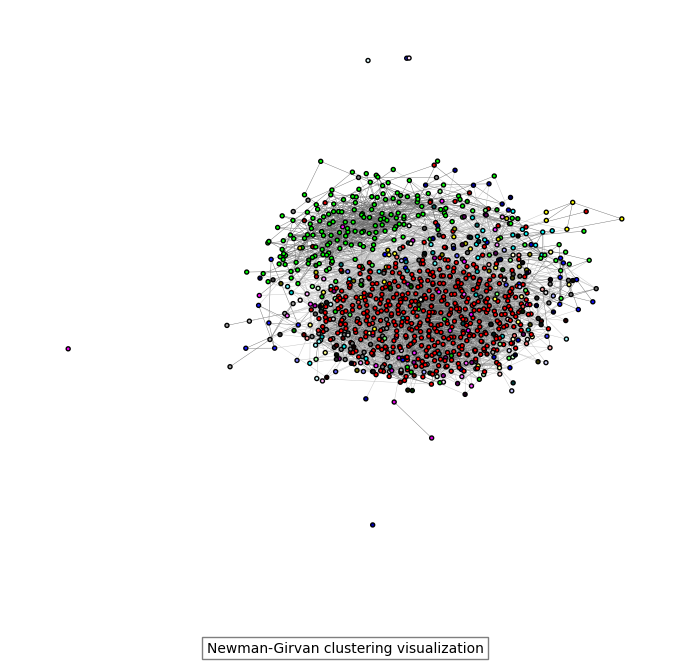

In [25]:
# Visualize Newman-Girvan algorithm clustering
import matplotlib.pyplot as plt
from igraph import plot

fig, ax = plt.subplots(figsize=(7, 7))
layout = graph.layout("kk")
visual_style = {
    "vertex_color": [i for i in best_ng_clusters.membership],
    "vertex_size": 4,
    "edge_width": 0.3,
    "layout": layout,
    "target": ax,
    "bbox": (400, 400)
}

plot(best_ng_clusters, **visual_style)
caption = (
    f"Newman-Girvan clustering visualization"
)
plt.figtext(
    0.5, 0.01,
    caption,
    ha="center",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.5, "pad": 3},
    wrap=True
)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

---
**Adjacency Matrix Visualization based on clustering**

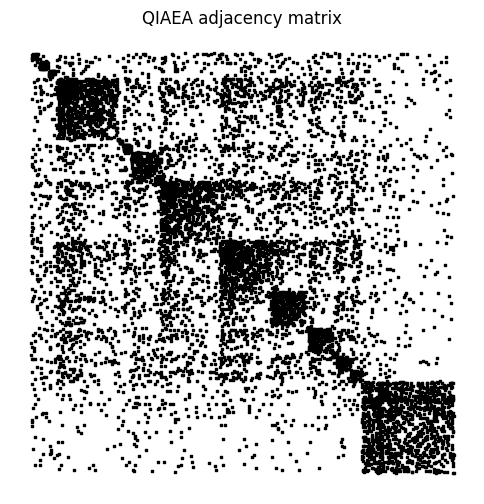

In [26]:
# QIAEA adjacency matrix visualization

adj_matrix = np.zeros((VERTICES_NUMBER, VERTICES_NUMBER))

membership = best_qiaea_clusters.membership
clusters = [[] for _ in range(max(membership)+1)]
for vertex, cluster in enumerate(membership):
    clusters[cluster].append(vertex)

adj_list = network.adjacency_list
# calculate positions of the vertices in sorted way according to clustering
positions = [0 for _ in range(3000)]
idx = 0
for cluster in clusters:
    for vertex in cluster:
        positions[vertex] = idx
        idx += 1
# calculate adjacency matrix
for cluster in clusters:
    for vertex in cluster:
        for neighbour in adj_list[vertex]:
            adj_matrix[positions[vertex]][positions[neighbour]] = 1

rows, cols = adj_matrix.nonzero()

plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=1, marker='s', c='black')
plt.gca().invert_yaxis()
plt.axis('off')
plt.title("QIAEA adjacency matrix")
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

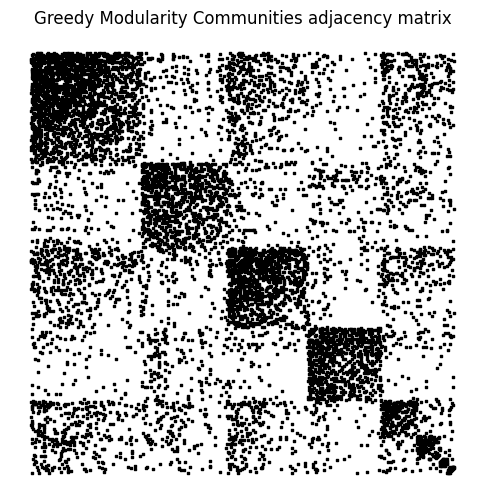

In [27]:
# Greedy Modularity Communities adjacency matrix visualization

adj_matrix = np.zeros((VERTICES_NUMBER, VERTICES_NUMBER))

membership = best_greedy_clusters.membership
clusters = [[] for _ in range(max(membership)+1)]
for vertex, cluster in enumerate(membership):
    clusters[cluster].append(vertex)

adj_list = network.adjacency_list
# calculate positions of the vertices in sorted way according to clustering
positions = [0 for _ in range(3000)]
idx = 0
for cluster in clusters:
    for vertex in cluster:
        positions[vertex] = idx
        idx += 1
# calculate adjacency matrix
for cluster in clusters:
    for vertex in cluster:
        for neighbour in adj_list[vertex]:
            adj_matrix[positions[vertex]][positions[neighbour]] = 1

rows, cols = adj_matrix.nonzero()

plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=1, marker='s', c='black')
plt.gca().invert_yaxis()
plt.axis('off')
plt.title('Greedy Modularity Communities adjacency matrix')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

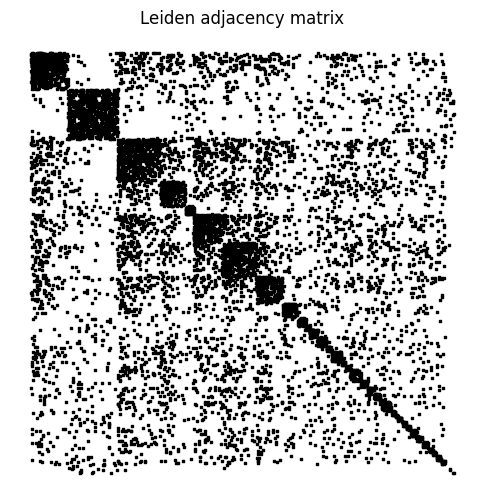

In [28]:
# Leiden adjacency matrix visualization

adj_matrix = np.zeros((VERTICES_NUMBER, VERTICES_NUMBER))

membership = best_leiden_clusters.membership
clusters = [[] for _ in range(max(membership)+1)]
for vertex, cluster in enumerate(membership):
    clusters[cluster].append(vertex)

adj_list = network.adjacency_list
# calculate positions of the vertices in sorted way according to clustering
positions = [0 for _ in range(3000)]
idx = 0
for cluster in clusters:
    for vertex in cluster:
        positions[vertex] = idx
        idx += 1
# calculate adjacency matrix
for cluster in clusters:
    for vertex in cluster:
        for neighbour in adj_list[vertex]:
            adj_matrix[positions[vertex]][positions[neighbour]] = 1

rows, cols = adj_matrix.nonzero()

plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=1, marker='s', c='black')
plt.gca().invert_yaxis()
plt.axis('off')
plt.title('Leiden adjacency matrix')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

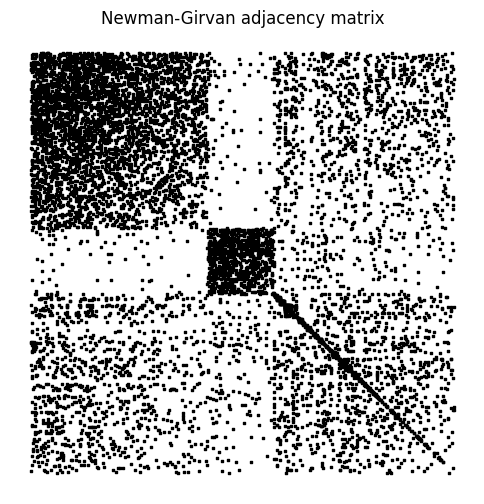

In [29]:
# Newman-Girvan adjacency matrix visualization

adj_matrix = np.zeros((VERTICES_NUMBER, VERTICES_NUMBER))

membership = best_ng_clusters.membership
clusters = [[] for _ in range(max(membership)+1)]
for vertex, cluster in enumerate(membership):
    clusters[cluster].append(vertex)

adj_list = network.adjacency_list
# calculate positions of the vertices in sorted way according to clustering
positions = [0 for _ in range(3000)]
idx = 0
for cluster in clusters:
    for vertex in cluster:
        positions[vertex] = idx
        idx += 1
# calculate adjacency matrix
for cluster in clusters:
    for vertex in cluster:
        for neighbour in adj_list[vertex]:
            adj_matrix[positions[vertex]][positions[neighbour]] = 1

rows, cols = adj_matrix.nonzero()

plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=1, marker='s', c='black')
plt.gca().invert_yaxis()
plt.axis('off')
plt.title('Newman-Girvan adjacency matrix')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()